Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']
Training Data: (455, 30)
Testing Data: (114, 30)

SVM Accuracy: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



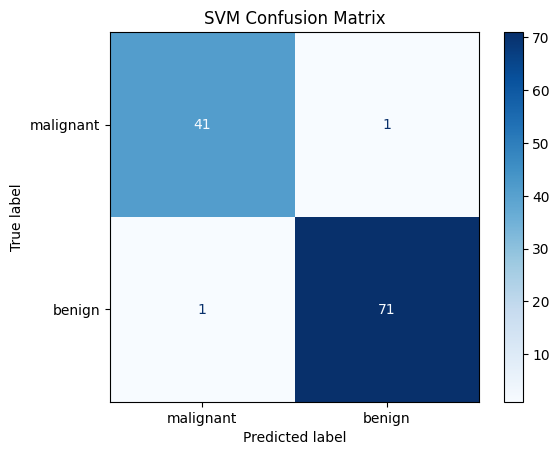


Number of Support Vectors:
[51 46]
Total Support Vectors: 97


In [1]:
# Step 1: Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Step 2: Load the dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

# Step 3: Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Step 4: Create SVM model with feature scaling

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

# Step 5: Train the model

model.fit(X_train, y_train)

# Step 6: Make predictions

y_pred = model.predict(X_test)

# Step 7: Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("\nSVM Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Step 8: Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

# Step 9: Display support vector information

svm_model = model.named_steps["svm"]

print("\nNumber of Support Vectors:")
print(svm_model.n_support_)

print("Total Support Vectors:", sum(svm_model.n_support_))